# Quickstart Notebook

This notebook loads a CSV dataset using the shared dataloader utilities.

In [1]:
from pathlib import Path
import sys

# Ensure project root is on sys.path for imports
project_root = Path.cwd()
while not (project_root / "main.py").exists() and project_root != project_root.parent:
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from dataloader import load_illness_data

df = load_illness_data("SCZ", in_notebook=True)

Loading data for illness SCZ at /Users/leonackermann/Library/CloudStorage/GoogleDrive-leonmax.ackermann@googlemail.com/My Drive/Uni/Master/4/MasterThesis/ml-genetics4psychiatry/data/tmpDATA-Leon/donnees_MRI_SCZ_only_variants_clumping_p_thr_0.0001all.txt


In [2]:
from dataloader import preprocess

X_train, y_train, X_test, y_test = preprocess(df=df, target="Z_scores_SCZ", testsize = 0.2)

# split X_train and y_train further into training and validation sets
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

In [3]:
from torch.utils.data import DataLoader
from dataloader import GWASDataset

train_loader = DataLoader(GWASDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(GWASDataset(X_val, y_val), batch_size=32, shuffle=False)
test_loader = DataLoader(GWASDataset(X_test, y_test), batch_size=32, shuffle=False)

In [36]:
from model import DNN, ResidualDNN

#model = DNN(input_dim=X_train.shape[1], hidden_dims=[50, 50, 50, 50, 50, 50], output_dim=1, dropout=0.2)
model = ResidualDNN(input_dim=X_train.shape[1], hidden_dims=[64,64,32,32], output_dim=1, dropout=0.4)
print(model)

ResidualDNN(
  (blocks): ModuleList(
    (0): ResidualBlock(
      (block): Sequential(
        (0): Linear(in_features=1010, out_features=64, bias=True)
        (1): ReLU()
        (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (3): Dropout(p=0.4, inplace=False)
        (4): Linear(in_features=64, out_features=64, bias=True)
        (5): ReLU()
        (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (7): Dropout(p=0.4, inplace=False)
      )
      (shortcut): Linear(in_features=1010, out_features=64, bias=True)
    )
    (1): ResidualBlock(
      (block): Sequential(
        (0): Linear(in_features=64, out_features=32, bias=True)
        (1): ReLU()
        (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (3): Dropout(p=0.4, inplace=False)
        (4): Linear(in_features=32, out_features=32, bias=True)
        (5): ReLU()
        (6): BatchNorm1d(32, e

In [37]:
from torch import nn, optim
import torch

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.00005, weight_decay=1e-5)

# learning rate scheduler
T_0 = 15
T_mult = 2
eta_min = 1e-6
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=T_0, T_mult=T_mult, eta_min=eta_min)
#scheduler = optim.lr_scheduler.CyclicLR(optimizer, base_lr=1e-7, max_lr=1e-5, step_size_up=10, mode='triangular2')
train_losses = []
test_losses = []
learning_rates = []

val_higher = 0
 
for epoch in range(200):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        # clip gradients to prevent exploding gradients
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * batch_X.size(0)
    scheduler.step()

    train_losses.append(total_loss / len(train_loader.dataset))
    learning_rates.append(optimizer.param_groups[0]['lr'])
    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader.dataset):.4f}")

    model.eval()
    test_loss = 0
    criterion = nn.MSELoss()
 
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            test_loss += loss.item() * batch_X.size(0)
    
    average_test_loss = test_loss / len(val_loader.dataset)
    test_losses.append(average_test_loss)
    print(f"Test Mean Squared Error: {average_test_loss:.4f}")

    # count number of epochs with higher validation loss than training loss
    if epoch > 0 and test_losses[-1] > test_losses[-2]:
        val_higher += 1
    else:        val_higher = 0

    if val_higher >= 20:
        print("Early stopping triggered due to 20 consecutive epochs with higher validation loss than training loss.")
        break

Epoch 1, Loss: 20.9733
Test Mean Squared Error: 20.1458
Epoch 2, Loss: 18.5745
Test Mean Squared Error: 19.0159
Epoch 3, Loss: 17.3218
Test Mean Squared Error: 18.4566
Epoch 4, Loss: 16.8337
Test Mean Squared Error: 18.1691
Epoch 5, Loss: 16.3943
Test Mean Squared Error: 18.0338
Epoch 6, Loss: 16.0746
Test Mean Squared Error: 17.7713
Epoch 7, Loss: 15.6266
Test Mean Squared Error: 17.8592
Epoch 8, Loss: 15.3697
Test Mean Squared Error: 17.6649
Epoch 9, Loss: 15.5314
Test Mean Squared Error: 17.4992
Epoch 10, Loss: 15.0813
Test Mean Squared Error: 17.5272
Epoch 11, Loss: 14.7332
Test Mean Squared Error: 17.4030
Epoch 12, Loss: 14.6784
Test Mean Squared Error: 17.4635
Epoch 13, Loss: 14.8048
Test Mean Squared Error: 17.4241
Epoch 14, Loss: 14.8585
Test Mean Squared Error: 17.5221
Epoch 15, Loss: 14.5129
Test Mean Squared Error: 17.4174
Epoch 16, Loss: 14.6127
Test Mean Squared Error: 17.2412
Epoch 17, Loss: 14.2642
Test Mean Squared Error: 17.1667
Epoch 18, Loss: 13.7704
Test Mean Square

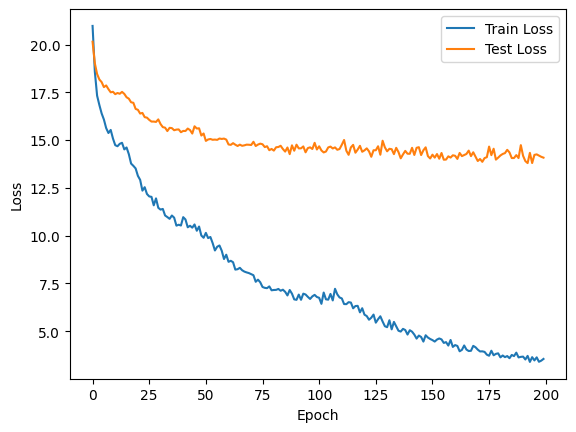

In [38]:
# plot training and test losses
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [39]:
# get the r2 score of the dnn model on test test
preds = model(torch.tensor(X_test, dtype=torch.float32)).detach().numpy()
from sklearn.metrics import r2_score
r2 = r2_score(y_test, preds)
print(f"R2 score of DNN model on test set: {r2}")

R2 score of DNN model on test set: 0.3624582105529217


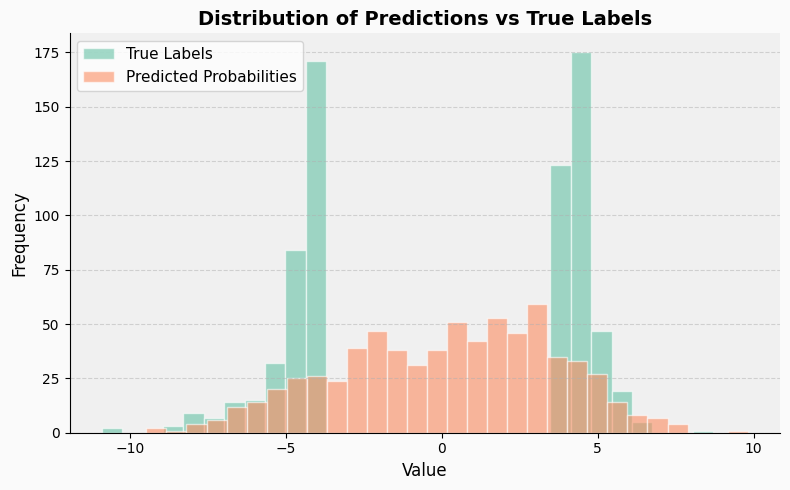

In [60]:
# just # Plot distribution of predictions vs true labels
fig, ax = plt.subplots(figsize=(8, 5))

ax.set_facecolor('#f0f0f0')
fig.patch.set_facecolor('#fafafa')

ax.hist(y_test, bins=30, alpha=0.6, label='True Labels', color='#66c2a5', edgecolor='white')
ax.hist(preds, bins=30, alpha=0.6, label='Predicted Probabilities', color='#fc8d62', edgecolor='white')

ax.set_xlabel('Value', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Predictions vs True Labels', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

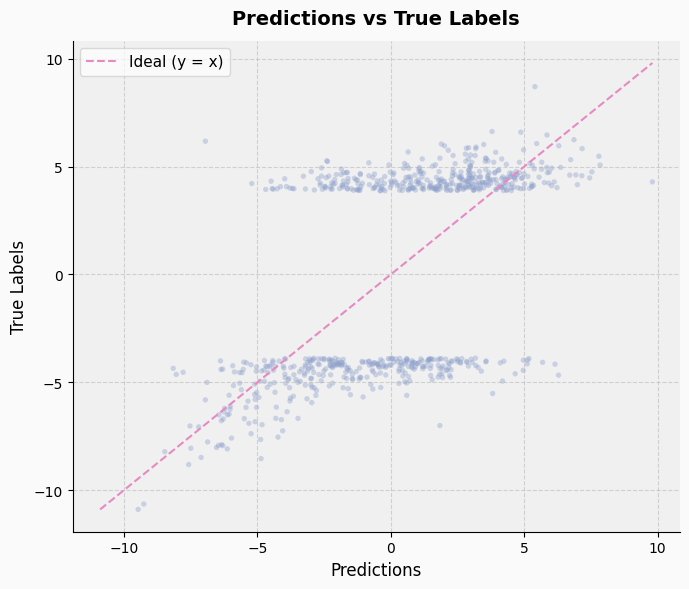

In [61]:
# plot predictions (x) vs true labels (y)
import numpy as np

fig, ax = plt.subplots(figsize=(7, 6))
ax.set_facecolor('#f0f0f0')
fig.patch.set_facecolor('#fafafa')

preds_flat = preds.flatten()
y_test_np = y_test.values if hasattr(y_test, 'values') else np.array(y_test)

ax.scatter(preds_flat, y_test_np, alpha=0.4, s=15, color='#8da0cb', edgecolors='none')

# identity line
lims = [min(preds_flat.min(), y_test_np.min()), max(preds_flat.max(), y_test_np.max())]
ax.plot(lims, lims, '--', color='#e78ac3', linewidth=1.5, label='Ideal (y = x)')

ax.set_xlabel('Predictions', fontsize=12)
ax.set_ylabel('True Labels', fontsize=12)
ax.set_title('Predictions vs True Labels', fontsize=14, fontweight='bold', pad=12)
ax.legend(fontsize=11, framealpha=0.7)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

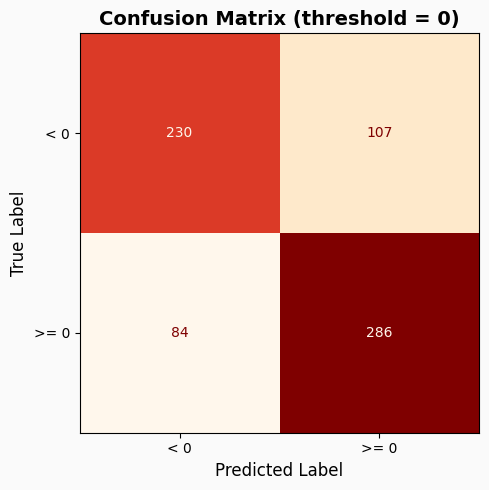

    Classification Metrics (thr = 1)
  Accuracy:    0.7298
  Precision:   0.7277
  Recall:      0.7730
  F1 Score:    0.7497

Classification Report:
              precision    recall  f1-score   support

         < 0       0.73      0.68      0.71       337
        >= 0       0.73      0.77      0.75       370

    accuracy                           0.73       707
   macro avg       0.73      0.73      0.73       707
weighted avg       0.73      0.73      0.73       707



In [55]:
# Binary classification at threshold = 1
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

threshold = 0
y_true_bin = (y_test_np >= threshold).astype(int)
y_pred_bin = (preds_flat >= threshold).astype(int)

# Confusion matrix plot
cm = confusion_matrix(y_true_bin, y_pred_bin)
fig, ax = plt.subplots(figsize=(6, 5))
ax.set_facecolor('#f0f0f0')
fig.patch.set_facecolor('#fafafa')
disp = ConfusionMatrixDisplay(cm, display_labels=[f'< {threshold}', f'>= {threshold}'])
disp.plot(ax=ax, cmap='OrRd', values_format='d', colorbar=False)
ax.set_title(f'Confusion Matrix (threshold = {threshold})', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Classification metrics
accuracy = accuracy_score(y_true_bin, y_pred_bin)
precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
recall = recall_score(y_true_bin, y_pred_bin, zero_division=0)
f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)

print("=" * 40)
print("    Classification Metrics (thr = 1)")
print("=" * 40)
print(f"  Accuracy:    {accuracy:.4f}")
print(f"  Precision:   {precision:.4f}")
print(f"  Recall:      {recall:.4f}")
print(f"  F1 Score:    {f1:.4f}")
print("=" * 40)

print("\nClassification Report:")
print(classification_report(y_true_bin, y_pred_bin,
                            target_names=[f'< {threshold}', f'>= {threshold}'],
                            zero_division=0))